In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\arici\OneDrive\Desktop\Data Science\ds-studio-ii\Project 1\instagram_usage_lifestyle.csv")

In [5]:
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [6]:
df.columns

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

In [7]:
#Delete unneccsary columuns
df = df.drop(columns=["app_name","urban_rural", 'education_level', 'smoking', 'alcohol_frequency', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic', 'daily_steps_count', 
       'social_events_per_month', 'books_read_per_year','volunteer_hours_per_month', 
       'travel_frequency_per_year', 'sessions_per_day','posts_created_per_week', 
       'reels_watched_per_day', 'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week','dms_received_per_week', 
       'ads_viewed_per_day', 'ads_clicked_per_day','time_on_feed_per_day', 
       'time_on_explore_per_day', 'time_on_messages_per_day', 'time_on_reels_per_day', 
       'followers_count', 'following_count', 'uses_premium_features',
       'notification_response_rate', 'account_creation_year', 'last_login_date', 
       'average_session_length_minutes', 'content_type_preference', 'preferred_content_theme',
       'privacy_setting_level', 'two_factor_auth_enabled', 'biometric_login_used', 
       'linked_accounts_count', 'subscription_status', 'user_engagement_score',
       'country', 'diet_quality', 'user_id'])

In [8]:
df.columns

Index(['age', 'gender', 'income_level', 'employment_status',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'perceived_stress_score',
       'self_reported_happiness', 'weekly_work_hours', 'hobbies_count',
       'daily_active_minutes_instagram'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 13 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   age                             1547896 non-null  int64  
 1   gender                          1547896 non-null  object 
 2   income_level                    1547896 non-null  object 
 3   employment_status               1547896 non-null  object 
 4   relationship_status             1547896 non-null  object 
 5   has_children                    1547896 non-null  object 
 6   exercise_hours_per_week         1547896 non-null  float64
 7   sleep_hours_per_night           1547896 non-null  float64
 8   perceived_stress_score          1547896 non-null  int64  
 9   self_reported_happiness         1547896 non-null  int64  
 10  weekly_work_hours               1547896 non-null  float64
 11  hobbies_count                   1547896 non-null  int64  
 12  

### Cleaning:
- Get rid of duplicate sets
- Check for null entries/missing data
- if no names, no identifier, whad do we do about that?
- Determine keys: What's the highest score per column, what's the lowest

In [10]:
#Getting rid of duplicates
df[['age', 'gender', 'income_level', 'employment_status',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'perceived_stress_score',
       'self_reported_happiness', 'weekly_work_hours', 'hobbies_count',
       'daily_active_minutes_instagram']].duplicated(keep=False).sum()

np.int64(0)

In [11]:
#There are no duplicates!?
duplicates = df[df[['age', 'gender', 'income_level', 'employment_status',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'perceived_stress_score',
       'self_reported_happiness', 'weekly_work_hours', 'hobbies_count',
       'daily_active_minutes_instagram']].duplicated(keep=False)]
duplicates.sort_values(by='age')

,age,gender,income_level,employment_status,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,weekly_work_hours,hobbies_count,daily_active_minutes_instagram


In [12]:
#Check for missing data
df.isnull().sum()

age                               0
gender                            0
income_level                      0
employment_status                 0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
perceived_stress_score            0
self_reported_happiness           0
weekly_work_hours                 0
hobbies_count                     0
daily_active_minutes_instagram    0
dtype: int64

In [13]:
#Sort data based off how much 
dfs = df.sort_values(by="daily_active_minutes_instagram")
print(dfs)

         age  gender  income_level   employment_status relationship_status  \
12        36  Female        Middle  Full-time employed              Single   
434555    34    Male        Middle  Full-time employed            Divorced   
434539    61  Female          High          Freelancer             Married   
1547866   17    Male           Low  Full-time employed   In a relationship   
1547863   28  Female  Lower-middle          Freelancer   In a relationship   
...      ...     ...           ...                 ...                 ...   
993357    18    Male          High  Full-time employed             Married   
116353    15    Male        Middle             Student              Single   
1141354   13    Male          High          Freelancer              Single   
1281062   21  Female        Middle          Freelancer   In a relationship   
253795    22    Male  Lower-middle             Student   In a relationship   

        has_children  exercise_hours_per_week  sleep_hours_per_

In [14]:
#Sanity check
dfs.describe()

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,weekly_work_hours,hobbies_count,daily_active_minutes_instagram
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,3.898544e+01,7.143480e+00,6.999384e+00,1.998774e+01,5.499804e+00,4.000145e+01,2.996140e+00,1.882298e+02
std,1.529453e+01,3.994556e+00,1.097098e+00,1.183258e+01,2.871232e+00,9.997320e+00,1.730508e+00,1.101278e+02
min,1.300000e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
25%,2.600000e+01,4.000000e+00,6.300000e+00,1.000000e+01,3.000000e+00,3.320000e+01,2.000000e+00,1.010000e+02
50%,3.900000e+01,6.600000e+00,7.000000e+00,2.000000e+01,5.000000e+00,4.000000e+01,3.000000e+00,1.860000e+02
75%,5.200000e+01,9.700000e+00,7.700000e+00,3.000000e+01,8.000000e+00,4.680000e+01,4.000000e+00,2.710000e+02
max,6.500000e+01,2.410000e+01,1.000000e+01,4.000000e+01,1.000000e+01,8.000000e+01,1.000000e+01,5.800000e+02


## Now for the Visualizations, starting with tracking trends in columns using time as the x variable

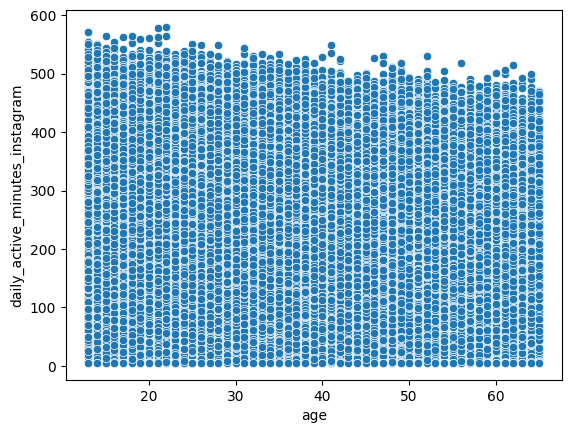

In [15]:
#Making a scatterplot
scatterplot = sns.scatterplot(
    data=df,
    y='daily_active_minutes_instagram',
    x='age'
)

the data set is too large. Use a Hexbin

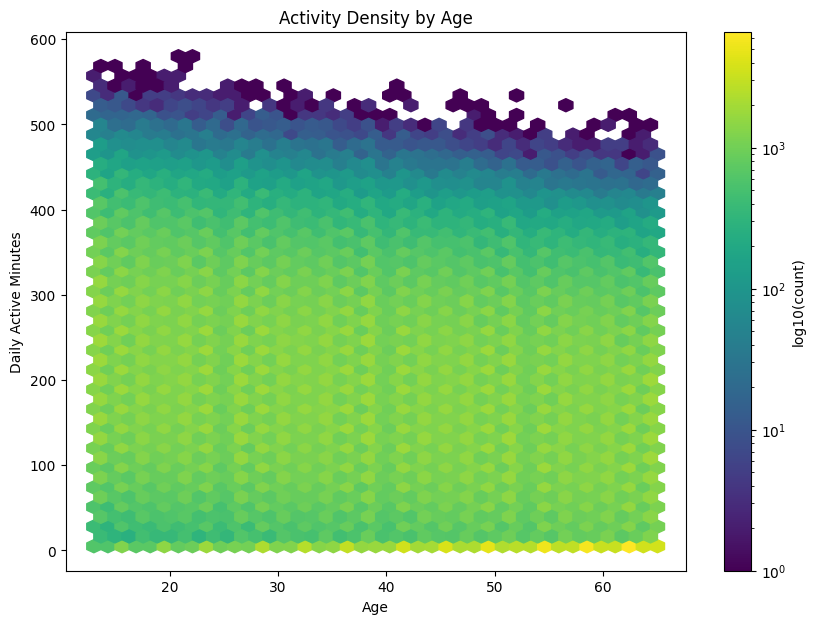

In [20]:
##Makin a hexbin graph with code help from Google Gemini
plt.figure(figsize=(10, 7))

hb = plt.hexbin(
    df['age'], 
    df['daily_active_minutes_instagram'], 
    gridsize=(40, 25),     
    cmap='viridis', 
    bins='log',          
    mincnt=1 
)

plt.colorbar(hb, label='log10(count)')
plt.xlabel('Age')
plt.ylabel('Daily Active Minutes')
plt.title('Activity Density by Age')

plt.show()

Cool looking graph but age isn't the only variable we can use and is not the best indicator for happiness in this particular data set

## Let's find strong relationships using a correlation heatmap

<Axes: >

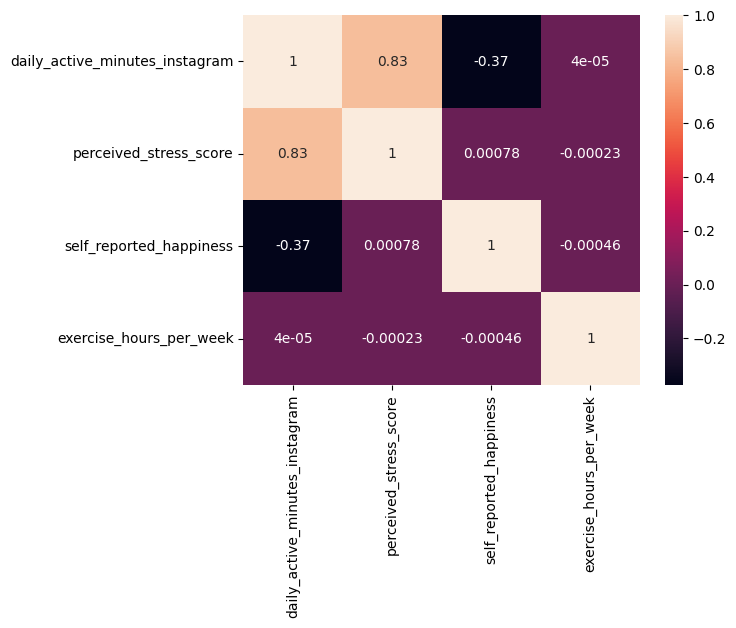

In [16]:
corr = dfs[['daily_active_minutes_instagram',
'perceived_stress_score',
'self_reported_happiness',
'exercise_hours_per_week']].corr()

sns.heatmap(corr, annot=True)

Now let's look more accurately into daily active minutes and stress score, and self perceived happiness.

<function matplotlib.pyplot.show(close=None, block=None)>

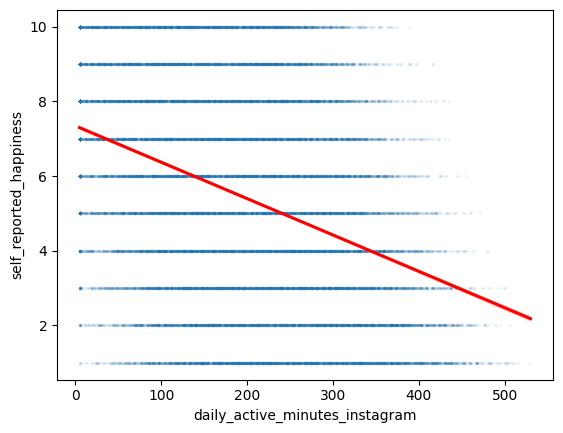

In [17]:
#Scatter plot with regression line. Dataset is large so we sample first
sample_df = dfs.sample(30000)

sns.regplot(
    x="daily_active_minutes_instagram",
    y='self_reported_happiness',
    data=sample_df,
    scatter_kws={'s':2, 'alpha':0.05},
    line_kws={'color':'red'}
)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

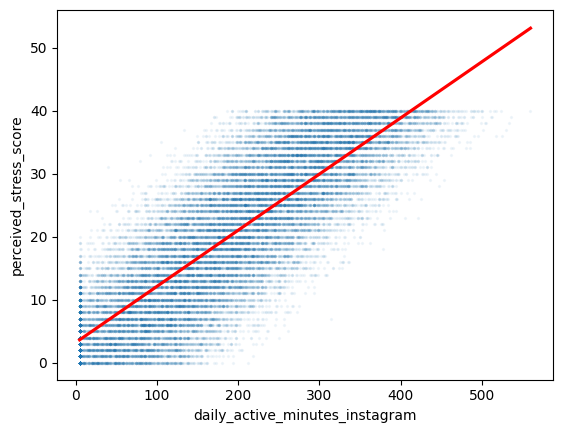

In [18]:
#Repeat with stress score instead of self percieved happiness
#Scatter plot with regression line. Dataset is large so we sample first
sample_df = dfs.sample(30000)

sns.regplot(
    x="daily_active_minutes_instagram",
    y='perceived_stress_score',
    data=sample_df,
    scatter_kws={'s':2, 'alpha':0.05},
    line_kws={'color':'red'}
)
plt.show